# NB03: Co-occurrence & Resistance Islands

**Goal**: Detect AMR gene co-occurrence patterns within species using phi coefficients.
Identify resistance islands (tightly co-occurring gene modules).

**Compute**: Local (30-60 min)

**Inputs**: `data/genome_amr_matrices/*.tsv`, `amr_census.csv`

**Outputs**:
- `data/resistance_islands.csv` — detected resistance islands
- `data/phi_summary.csv` — summary of phi coefficient distributions per species

In [1]:
import os
import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from itertools import combinations
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

PROJECT_DIR = Path(os.getcwd()).parent
ATLAS_DIR = PROJECT_DIR.parent / 'amr_pangenome_atlas'
DATA_DIR = PROJECT_DIR / 'data'
MATRIX_DIR = DATA_DIR / 'genome_amr_matrices'
FIG_DIR = PROJECT_DIR / 'figures'
FIG_DIR.mkdir(exist_ok=True)

plt.rcParams.update({'figure.dpi': 150, 'font.size': 10})

In [2]:
amr_census = pd.read_csv(ATLAS_DIR / 'data' / 'amr_census.csv')
amr_meta = amr_census[['gene_cluster_id', 'amr_gene', 'amr_product', 'mechanism']].drop_duplicates('gene_cluster_id')
amr_meta_dict = amr_meta.set_index('gene_cluster_id').to_dict('index')

eligible = pd.read_csv(DATA_DIR / 'eligible_species.csv')
print(f"AMR metadata: {len(amr_meta)} clusters")

AMR metadata: 82908 clusters


## 1. Phi Coefficient Computation

In [3]:
def compute_phi(vec_a, vec_b):
    """Compute phi coefficient between two binary vectors.
    Phi = Pearson correlation of two binary variables.
    """
    if vec_a.std() == 0 or vec_b.std() == 0:
        return np.nan
    return np.corrcoef(vec_a, vec_b)[0, 1]


def compute_phi_matrix(matrix):
    """Compute pairwise phi coefficients for all variable gene pairs."""
    # Only consider variable genes (5-95% prevalence)
    prevalence = matrix.mean(axis=0)
    variable_genes = prevalence[(prevalence > 0.05) & (prevalence < 0.95)].index.tolist()
    
    if len(variable_genes) < 2:
        return None, variable_genes
    
    n = len(variable_genes)
    phi_mat = np.full((n, n), np.nan)
    
    for i in range(n):
        phi_mat[i, i] = 1.0
        for j in range(i+1, n):
            phi = compute_phi(matrix[variable_genes[i]].values,
                              matrix[variable_genes[j]].values)
            phi_mat[i, j] = phi
            phi_mat[j, i] = phi
    
    return pd.DataFrame(phi_mat, index=variable_genes, columns=variable_genes), variable_genes

## 2. Resistance Island Detection

In [4]:
def detect_islands(phi_df, min_size=3, min_phi=0.5):
    """Detect resistance islands via hierarchical clustering of phi matrix.
    
    An island is a cluster of >= min_size genes with mean pairwise phi > min_phi.
    """
    if phi_df is None or phi_df.shape[0] < min_size:
        return []
    
    # Convert phi to distance (1 - phi), handle NaN
    phi_vals = phi_df.values.copy()
    np.fill_diagonal(phi_vals, 0)
    dist = 1 - phi_vals
    dist = np.clip(dist, 0, 2)  # ensure valid distances
    np.fill_diagonal(dist, 0)
    
    # Handle NaN in distance matrix
    nan_mask = np.isnan(dist)
    if nan_mask.any():
        dist[nan_mask] = 1.0  # treat NaN as uncorrelated
    
    # Make symmetric
    dist = (dist + dist.T) / 2
    np.fill_diagonal(dist, 0)
    
    try:
        condensed = squareform(dist)
        Z = linkage(condensed, method='average')
        # Cut at distance corresponding to phi = min_phi
        labels = fcluster(Z, t=1 - min_phi, criterion='distance')
    except Exception:
        return []
    
    genes = phi_df.index.tolist()
    islands = []
    
    for cluster_id in set(labels):
        members = [genes[i] for i, l in enumerate(labels) if l == cluster_id]
        if len(members) < min_size:
            continue
        
        # Compute mean phi within cluster
        member_phi = phi_df.loc[members, members]
        upper_tri = member_phi.values[np.triu_indices(len(members), k=1)]
        mean_phi = np.nanmean(upper_tri)
        
        if mean_phi >= min_phi:
            islands.append({
                'genes': members,
                'size': len(members),
                'mean_phi': mean_phi,
            })
    
    return islands

## 3. Prevalence-Matched Null Model

In [5]:
def prevalence_matched_null(matrix, variable_genes, n_random=1000, seed=42):
    """Generate null distribution of phi values from prevalence-matched random pairs."""
    rng = np.random.default_rng(seed)
    prevalence = matrix[variable_genes].mean(axis=0)
    n_genomes = matrix.shape[0]
    
    null_phis = []
    for _ in range(n_random):
        # Pick two random genes
        g1, g2 = rng.choice(variable_genes, 2, replace=False)
        # Generate random binary vectors with same prevalence
        p1 = prevalence[g1]
        p2 = prevalence[g2]
        v1 = (rng.random(n_genomes) < p1).astype(int)
        v2 = (rng.random(n_genomes) < p2).astype(int)
        phi = compute_phi(v1, v2)
        if not np.isnan(phi):
            null_phis.append(phi)
    
    return np.array(null_phis)

## 4. Process All Species

In [6]:
matrix_files = sorted(MATRIX_DIR.glob('*.tsv'))
print(f"Processing {len(matrix_files)} species...")

all_islands = []
phi_summaries = []

for idx, mf in enumerate(matrix_files):
    species_id = mf.stem
    matrix = pd.read_csv(mf, sep='\t', index_col=0)
    
    if matrix.shape[0] < 10 or matrix.shape[1] < 3:
        continue
    
    # Compute phi matrix
    phi_df, variable_genes = compute_phi_matrix(matrix)
    
    if phi_df is None or len(variable_genes) < 3:
        phi_summaries.append({
            'gtdb_species_clade_id': species_id,
            'n_variable_genes': len(variable_genes) if variable_genes else 0,
            'n_pairs': 0,
            'mean_phi': np.nan,
            'n_islands': 0,
        })
        continue
    
    # Extract upper triangle phi values
    n = phi_df.shape[0]
    upper_phis = phi_df.values[np.triu_indices(n, k=1)]
    valid_phis = upper_phis[~np.isnan(upper_phis)]
    
    # Detect islands
    islands = detect_islands(phi_df)
    
    # Record islands
    for isl_idx, island in enumerate(islands):
        # Get mechanism annotations
        mechanisms = set()
        gene_names = []
        for g in island['genes']:
            if g in amr_meta_dict:
                mechanisms.add(amr_meta_dict[g].get('mechanism', 'Unknown'))
                gene_names.append(amr_meta_dict[g].get('amr_gene', g))
            else:
                gene_names.append(g)
        
        all_islands.append({
            'gtdb_species_clade_id': species_id,
            'island_id': f"{species_id}_island{isl_idx}",
            'size': island['size'],
            'mean_phi': island['mean_phi'],
            'gene_cluster_ids': '|'.join(island['genes']),
            'gene_names': '|'.join(gene_names),
            'mechanisms': '|'.join(sorted(mechanisms)),
        })
    
    phi_summaries.append({
        'gtdb_species_clade_id': species_id,
        'n_variable_genes': len(variable_genes),
        'n_pairs': len(valid_phis),
        'mean_phi': np.mean(valid_phis) if len(valid_phis) > 0 else np.nan,
        'median_phi': np.median(valid_phis) if len(valid_phis) > 0 else np.nan,
        'frac_positive_phi': (valid_phis > 0).mean() if len(valid_phis) > 0 else np.nan,
        'frac_strong_phi': (valid_phis > 0.5).mean() if len(valid_phis) > 0 else np.nan,
        'n_islands': len(islands),
    })
    
    if (idx + 1) % 100 == 0:
        print(f"  [{idx+1}/{len(matrix_files)}] {len(all_islands)} islands so far")

islands_df = pd.DataFrame(all_islands)
phi_summary_df = pd.DataFrame(phi_summaries)

print(f"\nTotal resistance islands: {len(islands_df)}")
print(f"Species with >= 1 island: {islands_df['gtdb_species_clade_id'].nunique()}")

Processing 1305 species...


  [100/1305] 148 islands so far


  [200/1305] 228 islands so far


  [300/1305] 298 islands so far


  [400/1305] 448 islands so far


...

  [900/1305] 1088 islands so far


  [1000/1305] 1214 islands so far


  [1100/1305] 1351 islands so far


  [1200/1305] 1433 islands so far


  [1300/1305] 1513 islands so far

Total resistance islands: 1517
Species with >= 1 island: 705


## 5. Null Model Comparison

In [7]:
# Run null model on a subset of species (those with enough variable genes)
test_species = phi_summary_df[
    (phi_summary_df['n_variable_genes'] >= 5) & 
    (phi_summary_df['n_pairs'] >= 10)
].nlargest(50, 'n_variable_genes')['gtdb_species_clade_id'].tolist()

observed_means = []
null_means = []

for species_id in test_species:
    matrix = pd.read_csv(MATRIX_DIR / f"{species_id}.tsv", sep='\t', index_col=0)
    phi_df, variable_genes = compute_phi_matrix(matrix)
    
    if phi_df is None:
        continue
    
    upper_phis = phi_df.values[np.triu_indices(phi_df.shape[0], k=1)]
    valid = upper_phis[~np.isnan(upper_phis)]
    if len(valid) == 0:
        continue
    
    null_phis = prevalence_matched_null(matrix, variable_genes)
    
    observed_means.append(np.mean(valid))
    null_means.append(np.mean(null_phis) if len(null_phis) > 0 else 0)

# Compare
obs = np.array(observed_means)
null = np.array(null_means)
t_stat, t_pval = stats.ttest_rel(obs, null)
print(f"Observed mean phi: {obs.mean():.3f} +/- {obs.std():.3f}")
print(f"Null mean phi:     {null.mean():.3f} +/- {null.std():.3f}")
print(f"Paired t-test: t={t_stat:.2f}, p={t_pval:.1e}")

Observed mean phi: 0.183 +/- 0.084
Null mean phi:     0.001 +/- 0.007
Paired t-test: t=15.44, p=1.8e-20


## 6. Characterize Islands

In [8]:
if len(islands_df) > 0:
    print(f"Island size distribution:")
    print(islands_df['size'].describe().round(2))
    print(f"\nMean phi distribution:")
    print(islands_df['mean_phi'].describe().round(3))
    print(f"\nMechanism composition of islands:")
    # Count mechanism types in islands
    mech_counts = islands_df['mechanisms'].str.split('|').explode().value_counts()
    print(mech_counts.head(10))
    print(f"\nIslands with mixed mechanisms: {(islands_df['mechanisms'].str.contains('\\|')).sum()}")
else:
    print("No resistance islands detected.")

Island size distribution:
count    1517.00
mean        6.17
std         4.59
min         3.00
25%         3.00
50%         4.00
75%         7.00
max        43.00
Name: size, dtype: float64

Mean phi distribution:
count    1517.000
mean        0.827
std         0.130
min         0.536
25%         0.725
50%         0.824
75%         0.950
max         1.000
Name: mean_phi, dtype: float64

Mechanism composition of islands:
mechanisms
Other/Unclassified        1026
Efflux                     954
Enzymatic inactivation     698
Oxidoreductase             694
Regulatory                 502
Beta-lactamase             341
Target modification        293
Cell wall modification     137
Ribosomal                    4
Name: count, dtype: int64

Islands with mixed mechanisms: 1343


In [9]:
# Save outputs
islands_df.to_csv(DATA_DIR / 'resistance_islands.csv', index=False)
phi_summary_df.to_csv(DATA_DIR / 'phi_summary.csv', index=False)

print(f"Saved resistance_islands.csv: {len(islands_df)} rows")
print(f"Saved phi_summary.csv: {len(phi_summary_df)} rows")

Saved resistance_islands.csv: 1517 rows
Saved phi_summary.csv: 1305 rows


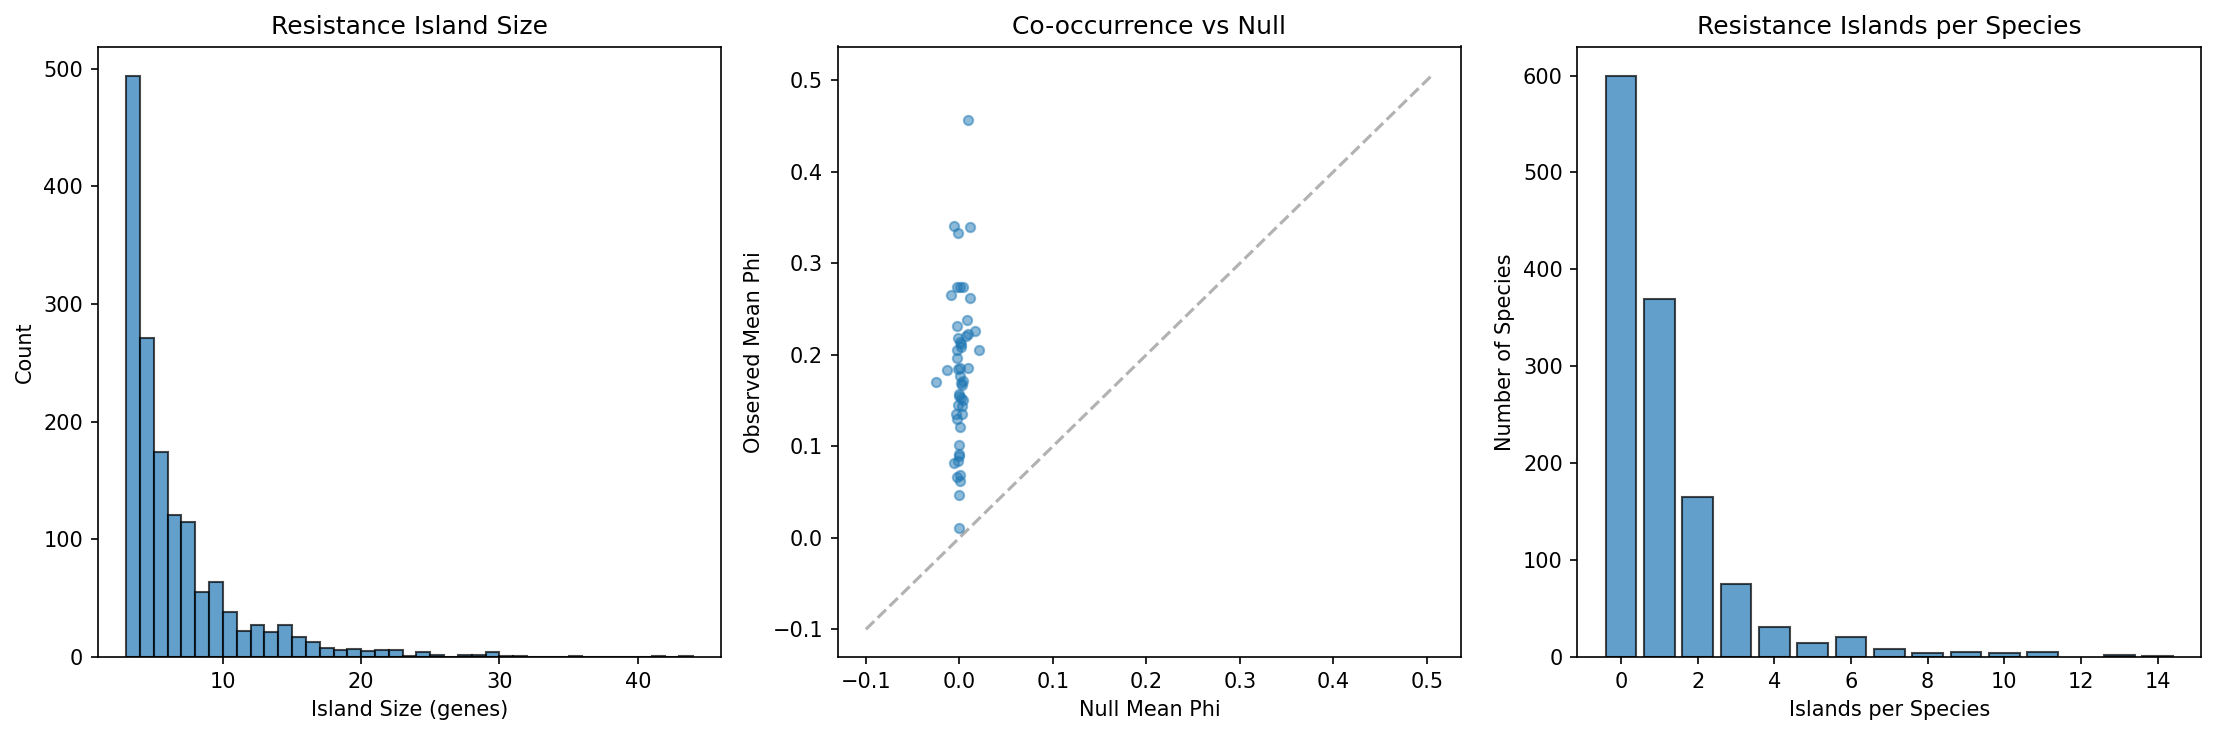

In [10]:
# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Island size distribution
ax = axes[0]
if len(islands_df) > 0:
    ax.hist(islands_df['size'], bins=range(3, islands_df['size'].max()+2),
            edgecolor='black', alpha=0.7)
ax.set_xlabel('Island Size (genes)')
ax.set_ylabel('Count')
ax.set_title('Resistance Island Size')

# Observed vs null phi
ax = axes[1]
ax.scatter(null_means, observed_means, alpha=0.5, s=20)
lim = max(max(null_means, default=0.1), max(observed_means, default=0.1)) + 0.05
ax.plot([-.1, lim], [-.1, lim], 'k--', alpha=0.3)
ax.set_xlabel('Null Mean Phi')
ax.set_ylabel('Observed Mean Phi')
ax.set_title('Co-occurrence vs Null')

# Islands per species
ax = axes[2]
island_counts = phi_summary_df['n_islands'].value_counts().sort_index()
ax.bar(island_counts.index, island_counts.values, edgecolor='black', alpha=0.7)
ax.set_xlabel('Islands per Species')
ax.set_ylabel('Number of Species')
ax.set_title('Resistance Islands per Species')

plt.tight_layout()
plt.savefig(FIG_DIR / 'nb03_cooccurrence.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
print("="*60)
print("NB03 SUMMARY")
print("="*60)
print(f"Species processed: {len(phi_summary_df)}")
print(f"Resistance islands detected: {len(islands_df)}")
print(f"Species with >= 1 island: {islands_df['gtdb_species_clade_id'].nunique() if len(islands_df) > 0 else 0}")
print(f"Mean island size: {islands_df['size'].mean():.1f}" if len(islands_df) > 0 else "N/A")
print(f"Observed vs null phi: {obs.mean():.3f} vs {null.mean():.3f} (p={t_pval:.1e})")

NB03 SUMMARY
Species processed: 1305
Resistance islands detected: 1517
Species with >= 1 island: 705
Mean island size: 6.2
Observed vs null phi: 0.183 vs 0.001 (p=1.8e-20)
